# Import libraries and modules

In [1]:
import Neural_Network_module
import Preprocessing_module
%matplotlib ipympl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import numpy as np

import torch
import torch.nn as nn
import pennylane as qml

from time import time
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
filepath = r'C:\Users\mathi\OneDrive\Documents\Studia\SGH\Semestr 4\Praca dyplomowa'

# Preprocess data and plot correlation and clusters

Deleted column: Operational setting 3
Deleted column: T2
Deleted column: P2
Deleted column: epr
Deleted column: farB
Deleted column: Nf_dmd
Deleted column: PCNfR_dmd


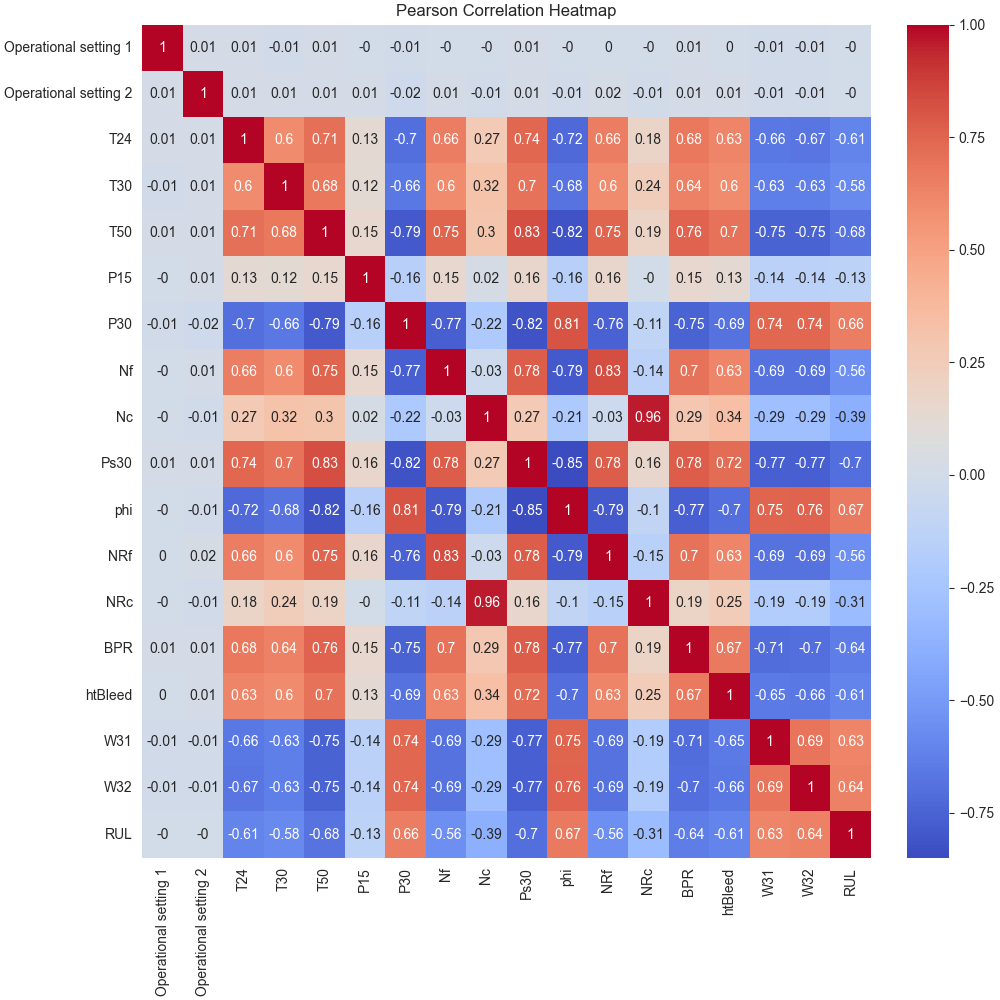

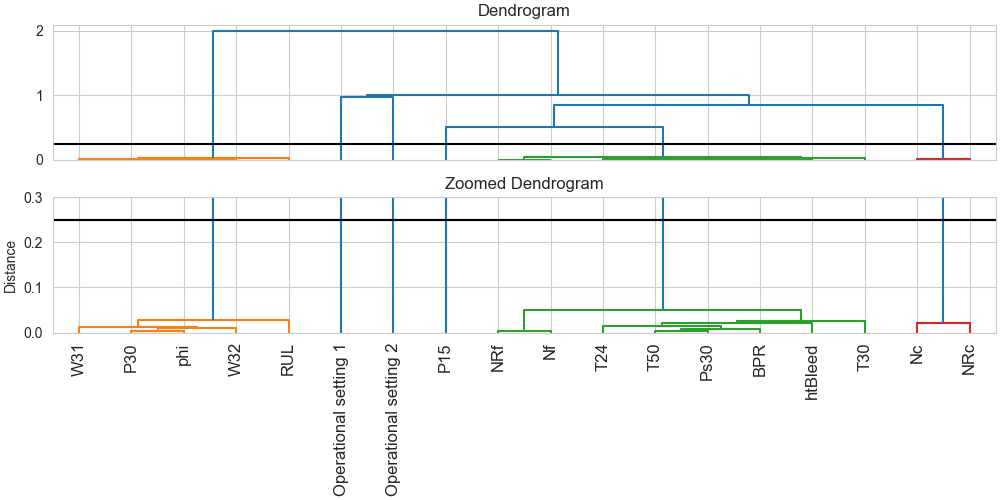

In [3]:
df = Preprocessing_module.main(max_distance=0.25)

In [4]:
df

,Operational setting 1,Operational setting 2,Ps30,P15,phi,Nc
0,-0.080460,-0.666667,-0.261905,1.0,0.266525,-0.780490
1,0.218391,-0.500000,-0.238095,1.0,0.530917,-0.799515
2,-0.494253,0.500000,-0.500000,1.0,0.590618,-0.719914
3,0.080460,0.000000,-0.666667,1.0,0.778252,-0.750965
4,-0.218391,-0.333333,-0.488095,1.0,0.492537,-0.700081
...,...,...,...,...,...,...
20626,-0.045977,-0.500000,0.452381,1.0,-0.658849,-0.607018
20627,-0.183908,-0.833333,0.416667,1.0,-0.577825,-0.610697
20628,0.045977,0.000000,0.476190,1.0,-0.437100,-0.603608
20629,-0.126437,0.500000,0.833333,1.0,-0.582090,-0.533429


# Neural Network

## Train models

In [ ]:
MODEL_NAMES = ['Autoencoder 1', 'Autoencoder 2', 'Autoencoder 3']

model1 = Neural_Network_module.Autoencoder_Linear1()
model2 = Neural_Network_module.Autoencoder_Linear2()
model3 = Neural_Network_module.Autoencoder_Linear3()

MODELS = [model1, model2, model3]

trained_model_neural1, mse_neural1, mae_neural1, losses_neural1, training_neural_time1  = Neural_Network_module.analyze_model(model1,df)
trained_model_neural2, mse_neural2, mae_neural2, losses_neural2, training_neural_time2  = Neural_Network_module.analyze_model(model2,df)
trained_model_neural3, mse_neural3, mae_neural3, losses_neural3, training_neural_time3  = Neural_Network_module.analyze_model(model3,df)

LOSSES = [losses_neural1, losses_neural2, losses_neural3]
TIMES = [training_neural_time1, training_neural_time2, training_neural_time3]


for model_name, model,loss_list,training_time in zip(MODEL_NAMES, MODELS, LOSSES, TIMES):
    path =filepath +f'\\Code\\Models\\{model_name}.pth'
    torch.save(model.state_dict(), path)
    torch.save({
    "model_state_dict": model.state_dict(),
    'model_name': model_name,
    "loss": loss_list,
    "training_time": training_time
}, path)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:07<00:00, 132.26it/s]


## Summarize Neural Network results

### Errors and training time summary

\begin{tabular}{lrrrr}
\toprule
Model & MSE & MAE & Training Time (s) & Epochs \\
\midrule
Autoencoder 1 & 0.104026 & 0.234260 & 4.066775 & 835 \\
Autoencoder 2 & 0.182718 & 0.363907 & 3.139281 & 1000 \\
Autoencoder 3 & 0.103150 & 0.225826 & 4.237583 & 555 \\
\bottomrule
\end{tabular}



,Model,MSE,MAE,Training Time (s),Epochs
0,Autoencoder 1,0.104026,0.234260,4.066775,835
1,Autoencoder 2,0.182718,0.363907,3.139281,1000
2,Autoencoder 3,0.103150,0.225826,4.237583,555


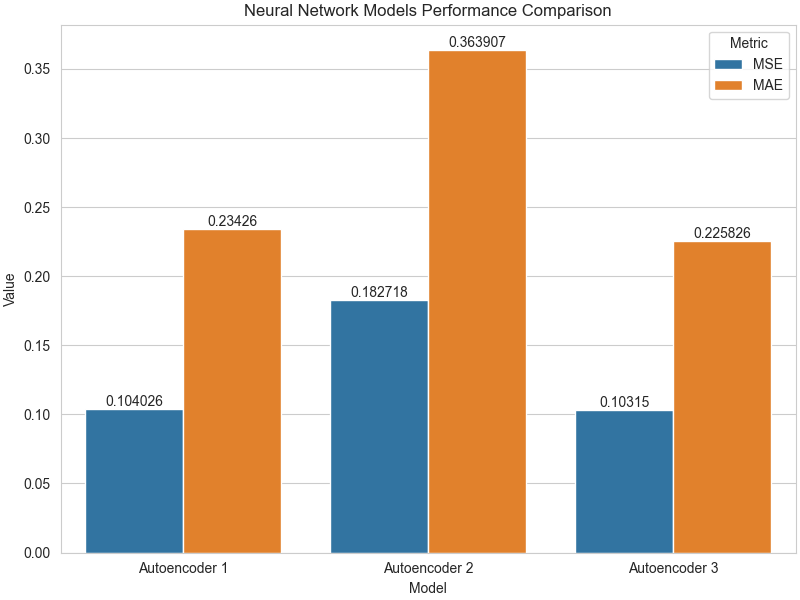

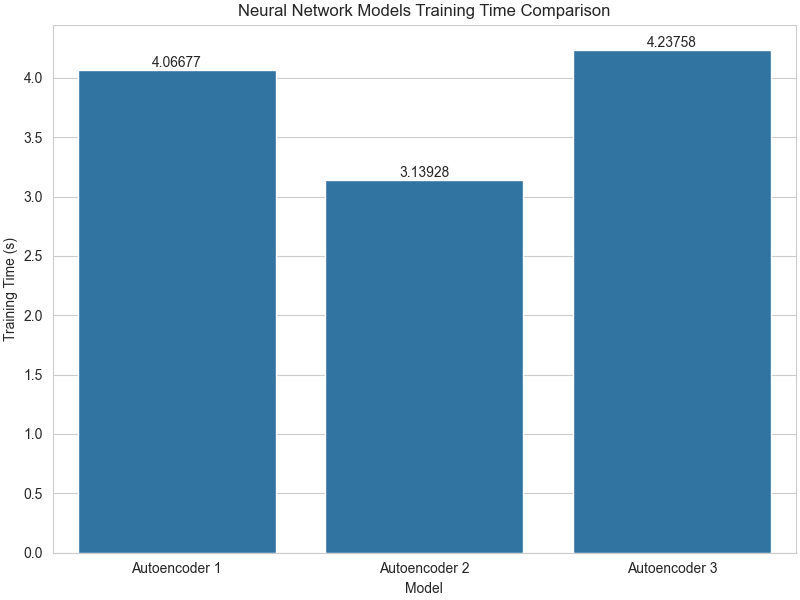

In [ ]:
df_neural_results = pd.DataFrame({
    'Model': MODEL_NAMES,
    'MSE': [mse_neural1, mse_neural2, mse_neural3],
    'MAE': [mae_neural1, mae_neural2, mae_neural3],
    'Training Time (s)': [training_neural_time1, training_neural_time2, training_neural_time3],
    'Epochs': [len(losses_neural1), len(losses_neural2), len(losses_neural3)]
})

df_neural_results.to_csv(f'{filepath}/Output/Model_Analysis/Neural_Network_Models_Results.csv', index=False)

df_bar_errors = df_neural_results[['Model', 'MSE', 'MAE']].melt(id_vars='Model', var_name='Metric', value_name='Value')

fig,axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.barplot(data=df_bar_errors, x='Model', y='Value', hue='Metric',ax=axes)
axes.bar_label(axes.containers[0], fontsize=10)
axes.bar_label(axes.containers[1], fontsize=10)
axes.set_title('Neural Network Models Performance Comparison')
fig.savefig(f'{filepath}/Output/Model_Analysis/Neural_Network_Models_Performance_Comparison.png', dpi=300)

fig,axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.barplot(data=df_neural_results, x='Model', y='Training Time (s)',ax=axes)
axes.bar_label(axes.containers[0], fontsize=10)
axes.set_title('Neural Network Models Training Time Comparison')
fig.savefig(f'{filepath}/Output/Model_Analysis/Neural_Network_Models_Training_Time_Comparison.png', dpi=300)

print(df_neural_results.to_latex(index=False))
df_neural_results


### Boxplot

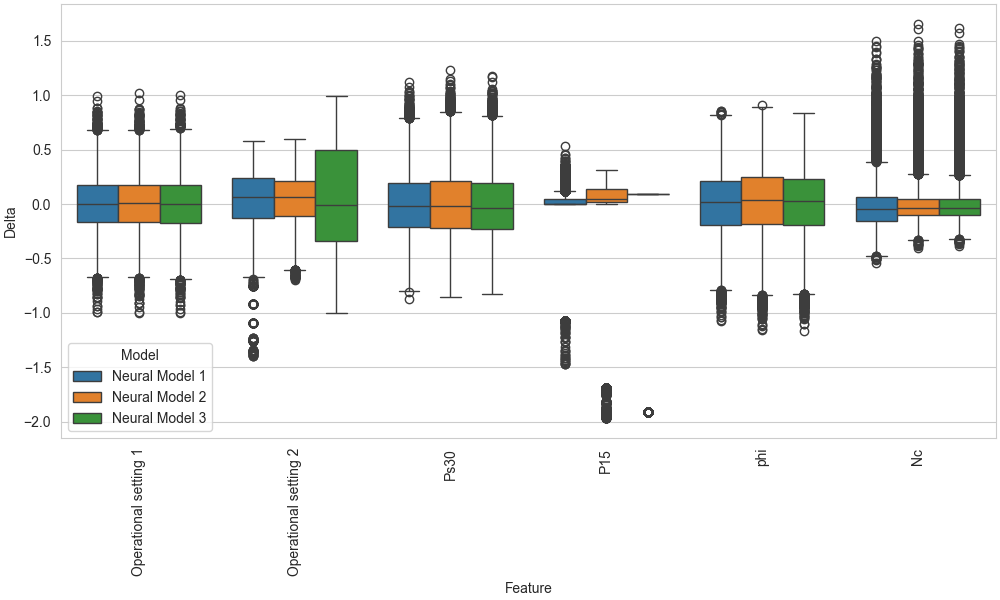

In [ ]:
delta_df_list = []
tensor_input = torch.tensor(df.values, dtype=torch.float32)
for model_, model_name in zip([trained_model_neural1, trained_model_neural2, trained_model_neural3], ['Neural Model 1', 'Neural Model 2', 'Neural Model 3']):
    tensor_output = model_(tensor_input)
    reconstructed_array = tensor_output.detach().cpu().numpy()
    df_recon_aux = pd.DataFrame(reconstructed_array, columns=df.columns)
    df_delta_aux=df-df_recon_aux
    df_delta_aux['Model'] = model_name
    delta_df_list.append(df_delta_aux)

df_neural_delta=pd.concat(delta_df_list,ignore_index=True)
df_neural_delta=df_neural_delta.melt(id_vars='Model',var_name='Sensor',value_name='Delta')
fig, axes = plt.subplots(figsize=(10, 6), layout='constrained')
axes.xaxis.set_tick_params(rotation=90)
sns.boxplot(x='Sensor', y='Delta', data=df_neural_delta,hue='Model')
axes.set_xlabel('Feature')

fig.savefig(f'{filepath}/Output/Model_Analysis/Neural_Network_Models_Delta_Boxplot_Comparison.png', dpi=300)

## Reconstruction

# Quantum Autoencoder

## Define parameters

In [5]:
n_qubits  = len(df.iloc[0,:]) # Number of features
n_latent  = 2 # Number of latent qubits i.e. comression to 2 qubits
n_trash   = n_qubits - n_latent
n_layers  = 2          # głębokość ansatzu (warstw entanglingowych)

latent_wires = list(range(n_latent))                  # np. [0,1]
trash_wires  = list(range(n_latent, n_qubits))        # np. [2,3,4,5]
BATCH_SIZE = 870


dev = qml.device("default.qubit", wires=n_qubits, shots=None)


# Przydatne: kształt wag StronglyEntanglingLayers
weight_shape = (n_layers, n_qubits)

## Quantum Circuit and Model Definition

### Encoder

In [6]:
def encoder(weights):
    """Encoder function.
    Entangles qubits and sets their Y rotation

    Args:
        weights (_type_): _description_
    """
    # iterate over layers
    for layer in range(n_layers):
        qml.BasicEntanglerLayers(weights=weights, wires=range(n_qubits))
        # Encode rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)

        # # Entangling CNOTs in a chain
        # for i in range(n_qubits - 1):
        #     qml.CNOT(wires=[i, i + 1])

### Decoder

In [7]:
def decoder(weights):
    """Decoder Function
    Entangles qubits and sets their Y rotation

    Args:
        weights (_type_): _description_
    """
   # iterate over layers
    for layer in range(n_layers):
        # Encode rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)

        # # Entangling CNOTs in a chain
        # for i in range(n_qubits - 1):
        #     qml.CNOT(wires=[i, i + 1])

### Qnode Full Autoencoder

In [8]:
# @qml.qnode(dev, interface="torch", diff_method="best")
# def decode_qnode(x, encoder_weight, decoder_weight):
#     """Autoencoder QNODE

#     Args:
#         x (list): list of entry data
#         encoder_weight (torch.tensor): list of weights for the encoder
#         decoder_weight (torch.tensor): list of weights for the decoder

#     Returns:
#         torch.tensor: list of expected values of Pauli Z measurements of each cubits. Values [-1,1]
#     """
#     # Loading data into quantum state
#     qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')

#     # Encode data
#     encoder(encoder_weight)

#     # Decode data
#     decoder(decoder_weight)

#     # Perform PauliZ measurment and get expected values for tyhose measurments
#     pauli_z_exp = [qml.expval(qml.PauliZ(qubit_no))
#                    for qubit_no in range(n_qubits)]

#     return pauli_z_exp

# Batched version of decode_qnode
@qml.qnode(dev, interface="torch", diff_method="best")  # adjoint zwykle przyspiesza
def decode_qnode_batch(X_batch, encoder_weight, decoder_weight):
    qml.AngleEmbedding(
        X_batch, wires=range(n_qubits), rotation="Y")
    encoder(encoder_weight)
    decoder(decoder_weight)
    # broadcast: dostaniesz tensory o kształcie (B, n_qubits)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


### Qnode for trash wires probabilty measurement




In [9]:
# @qml.batch_params
# @qml.qnode(dev, interface="torch", diff_method="best")
# def trash_zero_qnode(x, encoder_weights):
#     """QNODE used to measure the probability of trash qubits in bottleneck layer

#     Args:
#         x (list): input data
#         encoder_weights (torch.tensor): encoder weights

#     Returns:
#         torch.tensor: list of probabilities of measuring the state |0...0> on the trash wires
#     """

#     # Load data into quantum state
#     qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
#     encoder(encoder_weights)

#     probs = qml.probs(wires=trash_wires)
#     return probs

@qml.qnode(dev, interface="torch", diff_method="best")
def trash_zero_qnode_batch(X_batch, encoder_weight):
    qml.AngleEmbedding(
        X_batch, wires=range(n_qubits), rotation="Y")
   
    encoder(encoder_weight)
    # broadcast: kształt (B, 2**n_trash)
    probs = qml.probs(wires=trash_wires)
    return probs

### Qnode for latent state measurement




In [10]:
@qml.qnode(dev, interface="torch", diff_method="best")
def latent_state_values(x, encoder_weights):
    """Qnode used to measure the latent (nottleneck) layer

    Args:
        x (list): list of values used as entry
        encoder_weights (torch.tensor): list of weights for the encoder

    Returns:
        torch.tensor: list of expected values of Pauli Z measurements of each latent cubits. Values [-1,1]
    """
    # Load data into quantum state
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')

    # Encode data: entangler and rotations
    encoder(encoder_weights)

    # Perform PauliZ measurment and get expected values for tyhose measurments
    pauli_z_exp = [qml.expval(qml.PauliZ(w)) for w in latent_wires]

    return pauli_z_exp

### Pytorch Model

In [11]:
class QuantumAutoencoder(nn.Module):
    def __init__(self):
        """initialize en/decoder weights
        """
        super().__init__()
        # Parametry enkodera i dekodera (trainable)
        self.encoder_weight = nn.Parameter(
            torch.rand(size=weight_shape)*0.2-0.1)

        self.decoder_weight = nn.Parameter(
            torch.rand(size=weight_shape)*0.2-0.1)

    @staticmethod
    def _scale_input(x):
        """Scaling function left for legacy purposes. Returns unaltered value. Earlier it clamped on [-pi,pi]

        Args:
            x (_type_): _description_

        Returns:
            _type_: _description_
        """
        scaled = torch.clamp(x, -3.14159, 3.14159)  # legacy
        return x

    def forward(self, x):
        """Forward pass of class

        Args:
            x (torch.tensor): single row of torch tensor containing data

        Returns:
            torch.tensor, torch.tensor: list of reconstructed data, probability of trash wires being in |0...0>
        """
        single_input_flag = False
        if x.dim() == 1:
            x = x.unsqueeze(0)  # add batch dimension if missing
            single_input_flag = True

        # x_prim = decode_qnode(x, self.encoder_weight, self.decoder_weight)
        x_prim = decode_qnode_batch(x, self.encoder_weight, self.decoder_weight)

        if isinstance(x_prim, (list, tuple)):
            x_prim = torch.stack(x_prim, dim=1)

        # Measure probabilities of trash wires being in |0...0>
        probs_trash = trash_zero_qnode_batch(x, self.encoder_weight)
        # index 0 corresponds to |0...0>
        p_zero_trash = probs_trash[:, 0]

        if single_input_flag:
            x_prim = x_prim.squeeze(0)
            p_zero_trash = p_zero_trash.squeeze(0)

        return x_prim, p_zero_trash

    @staticmethod
    def loss_fn(batch, x_prim, p_zero_trash, alpha=1.0, beta=1):
        """Loss function

        Args:
            batch (torch.tensor): tensor shape [B, n_qubits]
            x_prim (torch.tensor): reconstructed tensor [B, n_qubits]
            p_zero (torch.tensor): tensor [B] of probability of trash wires being in |0...0>
            alpha (float, optional): reconstruction loss factor. Defaults to 1.0.
            beta (float, optional): compression loss factor. Defaults to 0.5.

        Returns:
            torch.tensor : 
            total loss, 
        """       
        recon_loss = torch.mean((x_prim - batch)**2)
        compression_loss = 1.0 - torch.mean(p_zero_trash)
        total_loss = alpha*recon_loss + beta*compression_loss
        return total_loss, recon_loss.item(), compression_loss.item()

        

### Estimate optimal batch size

In [12]:
def measure_train_time(batch_size, epochs):
    torch.manual_seed(0)
    model = QuantumAutoencoder()
    opt = torch.optim.Adam(model.parameters(), lr=0.02)
    X = torch.tensor(df.values, dtype=torch.float32)
    start_time_qantum = time()

    # shuffle data at the beginning of each epoch
    perm = torch.randperm(len(X))
    X_shuffled = X[perm]
    for batch_start in range(0, len(X), batch_size):

        opt.zero_grad()  # Zero the gradients

        batch = X_shuffled[batch_start:batch_start + batch_size]
        x_prim, p_zero_trash = model(batch)
        loss_q, recon_loss, compression_loss = model.loss_fn(batch, x_prim, p_zero_trash, alpha=1.0, beta=0.5)
        loss_q.backward()
        opt.step()
        break

    end_time_qantum = time() - start_time_qantum

    return end_time_qantum

wanna_measure=False

if wanna_measure:
    measurement_dict = {
        'Batch size': [],
        'Num batches': [],
        'Time per batch [s]': [],
        'Time per epoch [s]': [],
        'Estimated training time [s]': []
    }
    EPOCHS = 1000
    for batch_size in tqdm(np.logspace(0, np.log10(10000),dtype=int), position=0, desc='Time Measurment'):
        num_batches = math.ceil(len(df) / batch_size)
        time_per_batch = measure_train_time(int(batch_size), epochs=EPOCHS)
        if batch_size in measurement_dict['Batch size']:
            continue
        measurement_dict['Batch size'].append(batch_size)
        measurement_dict['Num batches'].append(num_batches)
        measurement_dict['Time per batch [s]'].append(time_per_batch)
        measurement_dict['Time per epoch [s]'].append(time_per_batch*num_batches)
        measurement_dict['Estimated training time [s]'].append(time_per_batch*num_batches*EPOCHS)

In [13]:
if wanna_measure:
    df_time_batch= pd.DataFrame(measurement_dict)
    fig, axes = plt.subplots(figsize=(10, 6), layout='constrained')

    df_time_batch.plot(x='Batch size',y='Estimated training time [s]',ax=axes,secondary_y=False)


    axes.set_ylabel('Time [s]')
    axes.set_xlabel('Batch size')


    secax = axes.secondary_yaxis(location=-0.1, functions=(lambda x: x/60, lambda x: x*60))
    secax.set_ylabel('Time [min]')
    df_time_batch.sort_values(by='Estimated training time [s]')

## Training

In [14]:
torch.manual_seed(0)
quantum_model = QuantumAutoencoder()
opt = torch.optim.Adam(quantum_model.parameters(), lr=0.02)
quantum_early_stopping = Neural_Network_module.EarlyStopping(patience=30, min_delta=5e-4)

# df = df.sample(n=200, random_state=42).reset_index(drop=True)
X = torch.tensor(df.values, dtype=torch.float32)

quantum_losses = {'Epoch': [], 'Total loss': [],
                  'Reconstruction loss': [], 'Compression loss': []}
start_time_qantum = time()
for epoch in tqdm(range(1000), position=0, desc='Epoch',):
    # shuffle data at the beginning of each epoch
    perm = torch.randperm(len(X))
    X_shuffled = X[perm]
    num_batches = math.ceil(len(X) / BATCH_SIZE)

    total_epoch_loss = 0.0
    total_epoch_recon_loss = 0.0
    total_epoch_compr_loss = 0.0

    for batch_start in range(0, len(X), BATCH_SIZE):
        total_batch_loss = 0.0
        opt.zero_grad()  # Zero the gradients

        batch = X_shuffled[batch_start:batch_start + BATCH_SIZE]
        x_prim, p_zero_trash = quantum_model(batch)
        loss_q, recon_loss, compression_loss = quantum_model.loss_fn(
            batch, x_prim, p_zero_trash, alpha=1.0, beta=0.5)
        loss_q.backward()
        opt.step()
        total_epoch_loss += loss_q.item()
        total_epoch_recon_loss += recon_loss
        total_epoch_compr_loss += compression_loss

    avg_epoch_total_loss = total_epoch_loss / num_batches
    avg_epoch_recon_loss = total_epoch_recon_loss/num_batches
    avg_epoch_compr_loss = total_epoch_compr_loss/num_batches

    quantum_losses['Epoch'].append(epoch)
    quantum_losses['Total loss'].append(avg_epoch_total_loss)
    quantum_losses['Reconstruction loss'].append(avg_epoch_recon_loss)
    quantum_losses['Compression loss'].append(avg_epoch_compr_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {quantum_losses['Total loss'][-1]:.6f}")

    # po policzeniu avg_epoch_total_loss
    
    quantum_early_stopping(avg_epoch_total_loss, quantum_model)
    if quantum_early_stopping.early_stop:
        print(f"\n⛔ Early stopping na epoce {epoch}")
        break

end_time_qantum = time() - start_time_qantum

Epoch:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: Loss = 0.600588
Epoch 11: Loss = 0.347023
Epoch 21: Loss = 0.347079
Epoch 31: Loss = 0.347040
🔁 Przywracam najlepsze wagi modelu...

⛔ Early stopping na epoce 34


## Save model

In [15]:
#torch.save(quantum_model.state_dict(), "quantum_autoencoder_weights.pth")

path =filepath +f'\\Code\\Models\\quantum_autoencoder_weights.pth'
torch.save({
"model_state_dict": quantum_model.state_dict(),
'model_name': 'Quantum',
"loss": quantum_losses,
"training_time": end_time_qantum
}, path)

## Reconsturuction

In [20]:
RECON_BATCH_SIZE = 100
reconstructions = []
quantum_model.eval()
with torch.no_grad():
    for batch_start in tqdm(range(0, X.shape[0], RECON_BATCH_SIZE)):
        batch_end = min(batch_start + RECON_BATCH_SIZE, X.shape[0])
        x_batch = X[batch_start:batch_end]
        x_prim, _ = quantum_model(x_batch)
        x_numpy = x_prim.detach().cpu().numpy()
        reconstructions.append(x_numpy)
reconstructions = np.vstack(reconstructions)

  0%|          | 0/207 [00:00<?, ?it/s]

 ### Error analysis

<Axes: xlabel='Sensor', ylabel='Delta'>

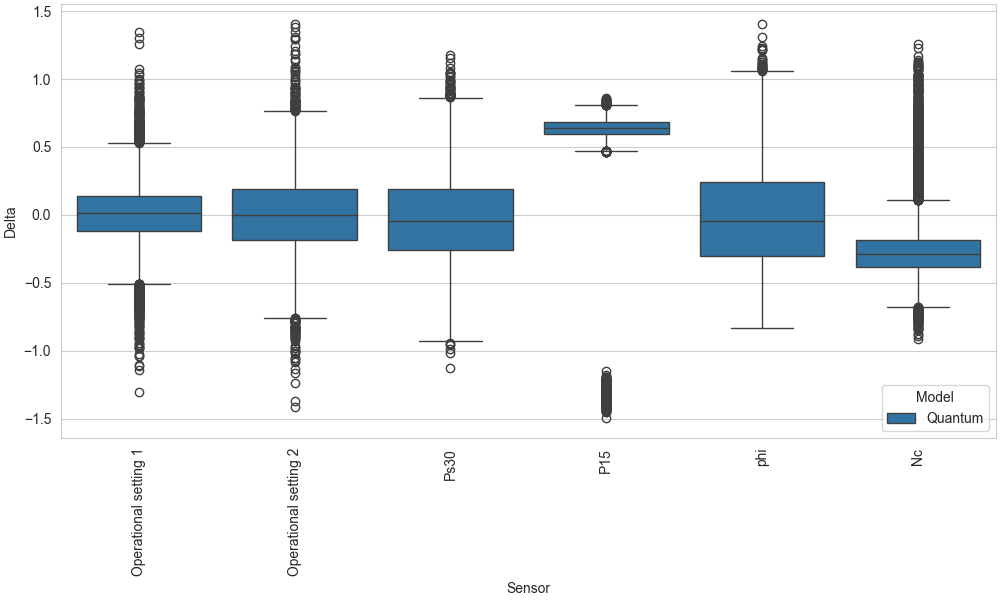

In [21]:
df_recon_q = pd.DataFrame(reconstructions,columns=df.columns)
df_delta_q = df - df_recon_q
df_delta_q['Model']='Quantum'
#df_neural_delta=pd.concat(delta_df_list,ignore_index=True)
df_delta_q=df_delta_q.melt(id_vars='Model',var_name='Sensor',value_name='Delta')
fig, axes = plt.subplots(figsize=(10, 6), layout='constrained')
axes.xaxis.set_tick_params(rotation=90)
sns.boxplot(x='Sensor', y='Delta', data=df_delta_q,hue='Model')

### MSE and MAE

In [22]:
q_mse = mean_squared_error(df,df_recon_q)
q_mae = mean_absolute_error(df,df_recon_q)
print(f'MSE = {q_mse:.3f}')
print(f'MAE = {q_mae:.3f}')

MSE = 0.154
MAE = 0.319


## Latent state inspection

In [19]:
latents = []
for i in range(10):  # pierwsze 10 próbek
    z = latent_state_values(X[i], quantum_model.encoder_weight)
    z= [x.detach().numpy() for x in z]
    latents.append(z)

latents = np.array(latents)
print(latents.shape)  # (10, 2) jeśli latent = 2 kubity
print(latents)

(10, 2)
[[0.54682066 0.41029572]
 [0.54263238 0.40138027]
 [0.50496174 0.34731255]
 [0.44284969 0.38858324]
 [0.5908414  0.44214311]
 [0.58943091 0.45264368]
 [0.64122927 0.45259748]
 [0.44629289 0.35939711]
 [0.62559354 0.50287371]
 [0.52187075 0.4704043 ]]


# Model comparison

## RMSE and Training time comparison

In [31]:
df_summary = pd.DataFrame(index=['RMSE','training time (s)'])
for model, losses in zip(['Neural Model 1','Neural Model 2','Neural Model 3'],
                         [(np.sqrt(losses_neural1[-1]), training_neural_time1),
                          (np.sqrt(losses_neural2[-1]), training_neural_time2),
                          (np.sqrt(losses_neural3[-1]), training_neural_time3)]):
    
    df_summary[model] = losses
df_summary['Quantum Model'] = [np.sqrt(q_mse), end_time_qantum]
df_summary.iloc[0,:] = df_summary.iloc[0,:].round(3)
df_summary.iloc[1,:] = df_summary.iloc[1,:].round(2)
print(df_summary.to_latex())
df_summary

\begin{tabular}{lrrrr}
\toprule
 & Neural Model 1 & Neural Model 2 & Neural Model 3 & Quantum Model \\
\midrule
RMSE & 0.254000 & 0.269000 & 0.322000 & 0.381000 \\
training time (s) & 5.000000 & 2.780000 & 5.350000 & 564.440000 \\
\bottomrule
\end{tabular}



,Neural Model 1,Neural Model 2,Neural Model 3,Quantum Model
RMSE,0.254,0.269,0.322,0.381
training time (s),5.000,2.780,5.350,564.440


## Reconstruction Delta Analysis

In [32]:
df_neural_delta.head()

,Model,Sensor,Delta
0,Neural Model 1,Operational setting 1,-0.070071
1,Neural Model 1,Operational setting 1,0.227120
2,Neural Model 1,Operational setting 1,-0.498337
3,Neural Model 1,Operational setting 1,0.083703
4,Neural Model 1,Operational setting 1,-0.210885


In [35]:
df_delta_q.head()

,Model,Sensor,Delta
0,Quantum,Operational setting 1,-0.018870
1,Quantum,Operational setting 1,0.265332
2,Quantum,Operational setting 1,-0.219356
3,Quantum,Operational setting 1,0.241020
4,Quantum,Operational setting 1,-0.128979


### Histograms

In [ ]:
print('Script finished successfully.')

C:\Users\mathi\AppData\Local\Temp\ipykernel_23456\1402570435.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(figsize=(8, 6), layout='constrained')


<Axes: xlabel='Delta', ylabel='Density'>

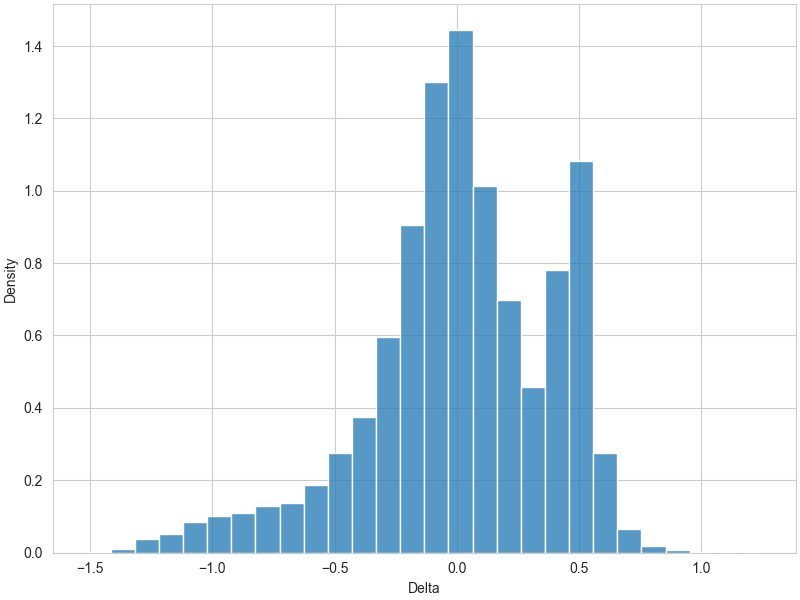

<Axes: xlabel='Delta', ylabel='Percent'>

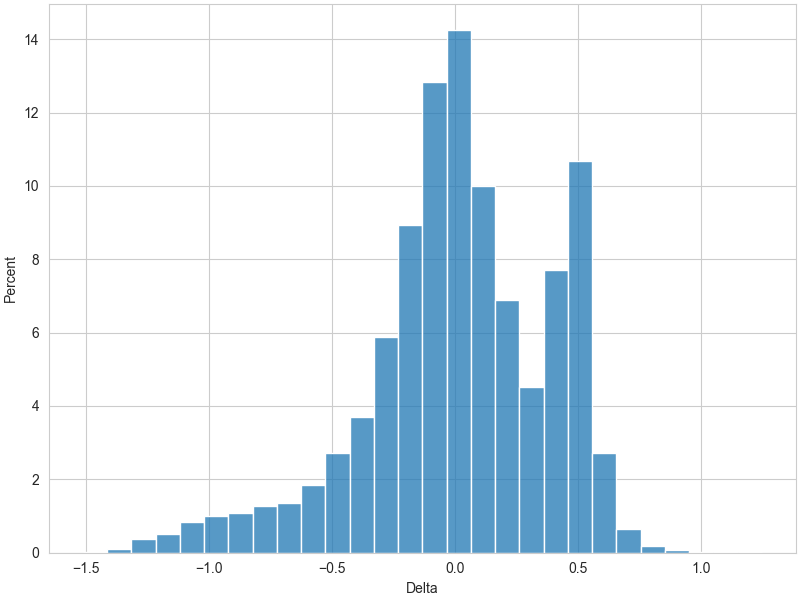

In [ ]:
fig, axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.histplot(data=df_delta_q,
             x='Delta',
             binwidth=0.1,
             stat='percent',
             axes=axes)

In [ ]:
delta_neural_hist = df_neural_delta.loc[df_neural_delta['Model']=='Neural Model 1']
fig, axes = plt.subplots(nrows=2,
                         ncols=len(delta_neural_hist['Delta'].unique()),
                         figsize=(10, 6), 
                         layout='constrained')
for i, sensor in enumerate(delta_neural_hist['Sensor'].unique()):
    print('Sensor:', sensor)
    neural_sensor = delta_neural_hist.loc(delta_neural_hist['Sensor']==sensor)
    quantum_sensor = df_delta_q.loc(df_delta_q['Sensor']==sensor)

    sns.histplot(data=neural_sensor,
             x='Delta',
             binwidth=0.1,
             stat='percent',
             axes=axes[0,i])
    axes[0,i].set_title(f'Neural Model 1 - {sensor}')
    
    sns.histplot(data=quantum_sensor,
             x='Delta',
             binwidth=0.1,
             stat='percent',
             axes=axes[1,i])
    axes[1,i].set_title(f'Quantum Model - {sensor}')
    

### Dataframes

## Loss visualization

Text(0.5, 1.0, 'Neural Network Models Performance Comparison')

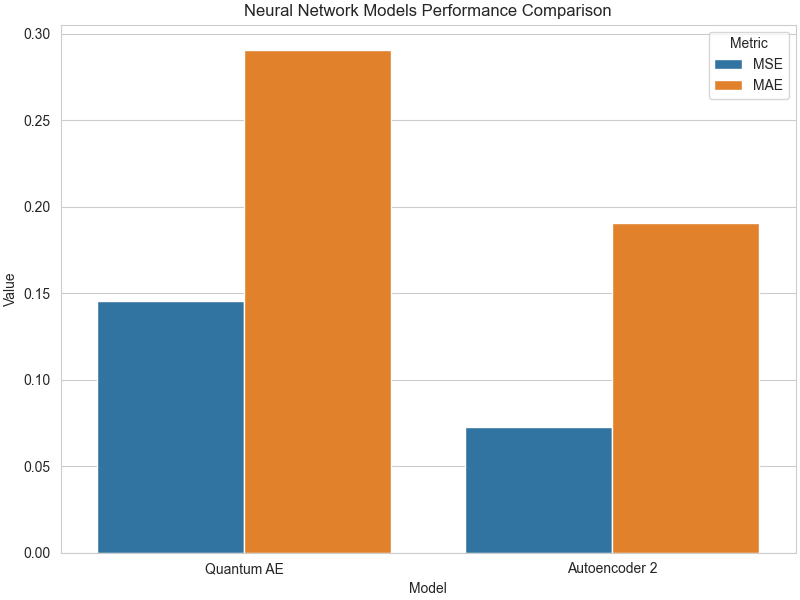

In [25]:
df_quantum_results = pd.DataFrame({
    'Model': ['Quantum AE', 'Autoencoder 2'],
    'MSE': [q_mse,mse_neural2],
    'MAE': [q_mae,mae_neural2],
    'Training Time (s)': [end_time_qantum, training_neural_time2]
})

df_bar_errors2 = df_quantum_results[['Model', 'MSE', 'MAE']].melt(id_vars='Model', var_name='Metric', value_name='Value')

fig,axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.barplot(data=df_bar_errors2, x='Model', y='Value', hue='Metric',ax=axes)
axes.set_title('Neural Network Models Performance Comparison')

In [26]:
df_quantum_losses=pd.DataFrame(quantum_losses)
df_quantum_losses_melted=df_quantum_losses.melt(id_vars='Epoch',value_name='Loss',var_name='Metric')

<Axes: xlabel='Epoch', ylabel='Loss'>

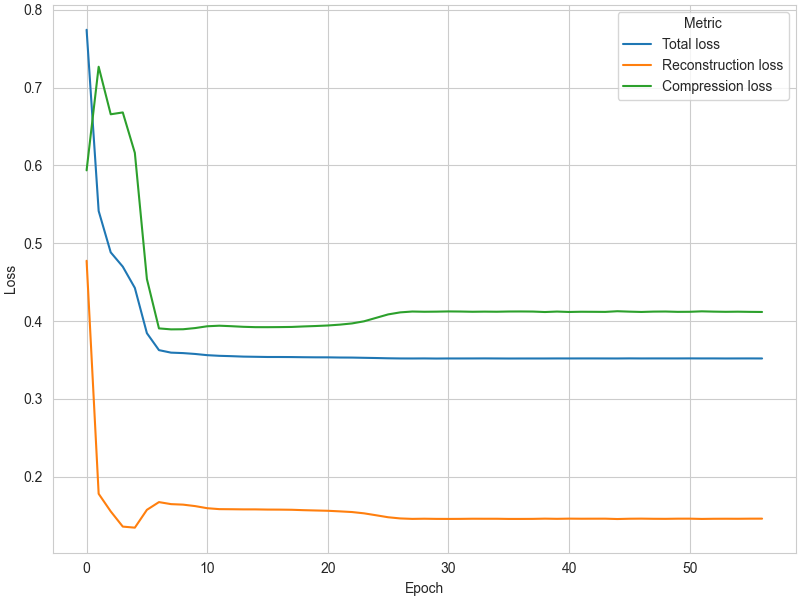

In [27]:
fig,axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.lineplot(df_quantum_losses_melted,x='Epoch',y='Loss',hue='Metric',ax=axes)


In [28]:
axes.plot(losses_neural2, label='Neural Network 2 Training Loss')
axes.legend()
axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')

Text(18.166999999999994, 0.5, 'Loss')

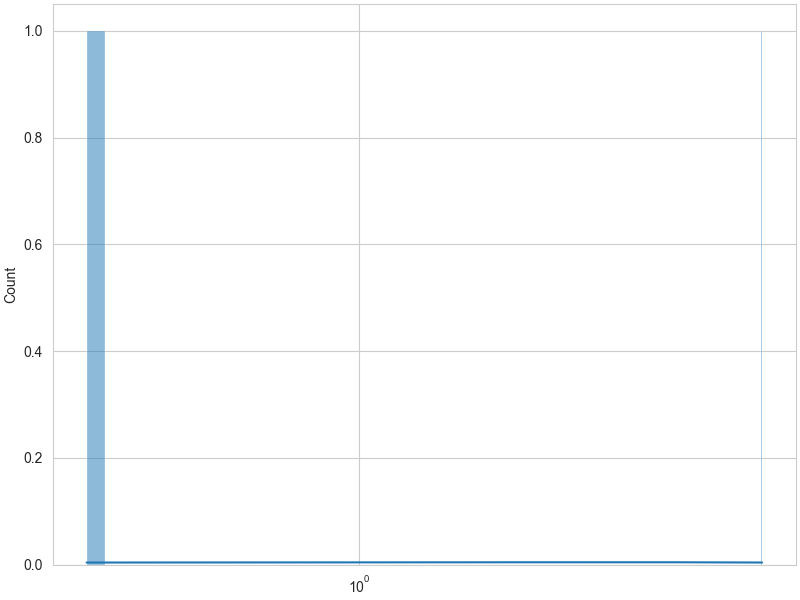

In [29]:
fig,axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.histplot(losses, bins=200, kde=True, ax=axes)
axes.set_xscale('log')